# 03 — Light-S architecture check

This notebook connects the SALICON pipeline to the first learned model.

It builds Light-S, checks the feature and output shapes, tests one real batch
with the saliency loss, and confirms that the small model can reduce the loss
on four repeated samples. Final training is done in the next notebook.


In [1]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import subprocess
import sys

REPO_URL = "https://github.com/RicoDalB/efficient-saliency-prediction.git"
REPO_ROOT = Path("/content/efficient-saliency-prediction")
DRIVE_ROOT = Path("/content/drive/MyDrive/saliency_project")
DATA_ROOT = DRIVE_ROOT / "data" / "SALICON"

if not REPO_ROOT.exists():
    subprocess.run(
        ["git", "clone", REPO_URL, str(REPO_ROOT)],
        check=True,
    )

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

TRAIN_MANIFEST_PATH = REPO_ROOT / "splits" / "train_manifest.csv"

assert REPO_ROOT.is_dir(), f"Repository not found: {REPO_ROOT}"
assert DATA_ROOT.is_dir(), f"SALICON data not found: {DATA_ROOT}"
assert TRAIN_MANIFEST_PATH.is_file(), f"Manifest not found: {TRAIN_MANIFEST_PATH}"

print("Repository:", REPO_ROOT)
print("Dataset:   ", DATA_ROOT)
print("Manifest:  ", TRAIN_MANIFEST_PATH)

Mounted at /content/drive
Repository: /content/efficient-saliency-prediction
Dataset:    /content/drive/MyDrive/saliency_project/data/SALICON
Manifest:   /content/efficient-saliency-prediction/splits/train_manifest.csv


In [23]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch

from src.data import SaliconDataset, build_dataloader
from src.losses_metrics import (
    saliency_loss,
    spatial_softmax,
    validate_spatial_distribution,
)
from src.models import build_model, parameter_summary

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_SIZE = (169, 256)  # (height, width), matching src/data.py
DECODER_CHANNELS = 32

print("Device:", DEVICE)
print("PyTorch:", torch.__version__)

Device: cuda
PyTorch: 2.11.0+cu128


## Build Light-S model

Light-S uses the deepest MobileNetV2 feature map and a small decoder. The
following checks keep the parts that matter before training: feature scales,
parameter count and final output shape.


In [24]:
model = build_model(
    "light_single",
    pretrained=True,
    decoder_channels=DECODER_CHANNELS,
).to(DEVICE)

summary = parameter_summary(model)
summary

{'encoder': 1811712, 'decoder': 14401, 'total': 1826113, 'trainable': 1826113}

In [25]:
dummy_images = torch.randn(
    1,
    3,
    OUTPUT_SIZE[0],
    OUTPUT_SIZE[1],
    device=DEVICE,
)

model.eval()
with torch.inference_mode():
    feature_maps = model.encoder(dummy_images)

for name, feature_map in feature_maps.items():
    print(f"{name}: {tuple(feature_map.shape)}")

assert set(feature_maps) == {"s4", "s8", "s16", "s32"}

s4: (1, 24, 43, 64)
s8: (1, 32, 22, 32)
s16: (1, 96, 11, 16)
s32: (1, 320, 6, 8)


In [26]:
with torch.inference_mode():
    dummy_logits = model(dummy_images)

print("Input shape: ", tuple(dummy_images.shape))
print("Output shape:", tuple(dummy_logits.shape))

assert dummy_logits.shape == (1, 1, *OUTPUT_SIZE)
assert torch.isfinite(dummy_logits).all()

print("Forward-pass check passed.")

Input shape:  (1, 3, 169, 256)
Output shape: (1, 1, 169, 256)
Forward-pass check passed.


## Real batch, loss and gradients

A real SALICON batch is passed through the model and the shared loss. This
checks that `data.py`, `models.py` and `losses_metrics.py` use the same tensor
contract.


In [28]:
train_dataset = SaliconDataset(
    manifest_path=TRAIN_MANIFEST_PATH,
    data_root=DATA_ROOT,
    image_column="image_relpath",
    map_column="map_relpath",
    id_column="sample_id",
    output_size=OUTPUT_SIZE,
    use_imagenet_normalization=True,
)

train_loader = build_dataloader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    seed=SEED,
    num_workers=0,
)

batch = next(iter(train_loader))
images = batch["image"].to(DEVICE)
targets = batch["target"].to(DEVICE)

print("Image batch: ", tuple(images.shape))
print("Target batch:", tuple(targets.shape))
print("Sample IDs:  ", batch["sample_id"])
print("Target mass: ", targets.flatten(start_dim=1).sum(dim=1))

assert images.shape == (4, 3, *OUTPUT_SIZE)
assert targets.shape == (4, 1, *OUTPUT_SIZE)
validate_spatial_distribution(targets, name="targets")

Image batch:  (4, 3, 169, 256)
Target batch: (4, 1, 169, 256)
Sample IDs:   ['460915', '372003', '564681', '220234']
Target mass:  tensor([1.0000, 1.0000, 1.0000, 1.0000], device='cuda:0')


In [29]:
model.train()
logits = model(images)
loss = saliency_loss(logits, targets)

print("Logit shape:", tuple(logits.shape))
print("Loss:", float(loss.detach()))

assert logits.shape == targets.shape
assert torch.isfinite(loss)

print("Model-loss integration check passed.")

Logit shape: (4, 1, 169, 256)
Loss: 1.7837347984313965
Model-loss integration check passed.


In [30]:
model.zero_grad(set_to_none=True)
loss.backward()

encoder_has_gradient = any(
    parameter.grad is not None
    for parameter in model.encoder.parameters()
    if parameter.requires_grad
)
decoder_has_gradient = any(
    parameter.grad is not None
    for parameter in model.decoder.parameters()
    if parameter.requires_grad
)

print("Encoder receives gradients:", encoder_has_gradient)
print("Decoder receives gradients:", decoder_has_gradient)

assert encoder_has_gradient
assert decoder_has_gradient

print("Backward-pass check passed.")

Encoder receives gradients: True
Decoder receives gradients: True
Backward-pass check passed.


## Tiny overfit check

The same four samples are optimized for a few steps. This is not the final
training run; it only confirms that the model and loss can learn together.


step 01/40 - loss: 1.4924
step 10/40 - loss: 0.3764
step 20/40 - loss: 0.2515
step 30/40 - loss: 0.1540
step 40/40 - loss: 0.0946


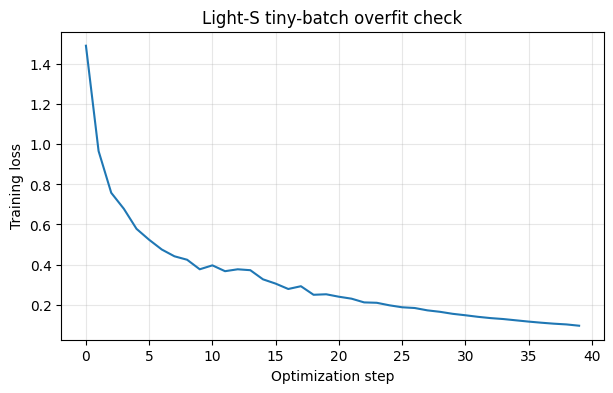

Initial loss: 1.4924306869506836
Final loss:   0.09457704424858093


In [32]:
tiny_model = build_model(
    "light_single",
    pretrained=True,
    decoder_channels=DECODER_CHANNELS,
).to(DEVICE)

tiny_optimizer = torch.optim.AdamW(
    tiny_model.parameters(),
    lr=1e-3,
    weight_decay=0.0,
)

tiny_losses = []
TINY_STEPS = 40

tiny_model.train()
for step in range(TINY_STEPS):
    tiny_optimizer.zero_grad(set_to_none=True)

    tiny_logits = tiny_model(images)
    tiny_loss = saliency_loss(tiny_logits, targets)
    tiny_loss.backward()
    tiny_optimizer.step()

    tiny_losses.append(float(tiny_loss.detach()))

    if step == 0 or (step + 1) % 10 == 0:
        print(f"step {step + 1:02d}/{TINY_STEPS} - loss: {tiny_losses[-1]:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(tiny_losses)
plt.xlabel("Optimization step")
plt.ylabel("Training loss")
plt.title("Light-S tiny-batch overfit check")
plt.grid(alpha=0.3)
plt.show()

print("Initial loss:", tiny_losses[0])
print("Final loss:  ", tiny_losses[-1])

## Result

Light-S returns the expected multi-depth encoder features and one saliency
logit per output pixel. The real-batch loss is finite, gradients reach both
parts of the network, and the tiny-batch loss decreases.

The redundant spatial-softmax test, untrained prediction figure, construction
of the other two models and the final checklist were removed. Those checks are
already covered elsewhere or do not contribute to the Light-S result.
